In [1]:
import pandas as pd 
from features import extract_features
from models import UNet, predict_masks, preprocess_image
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
model = UNet(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet_cell_nucleus_0208.pth"))
model.to(device)

UNet(
  (encoder1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder3): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Re

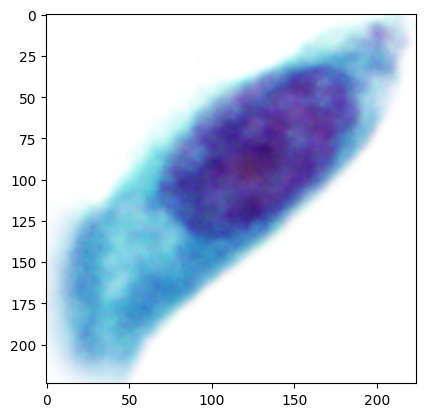

In [3]:
# image_path = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\single_all_clahe\2b_1.jpg"
image_path = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped2\HSIL\62b_1.bmp"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)


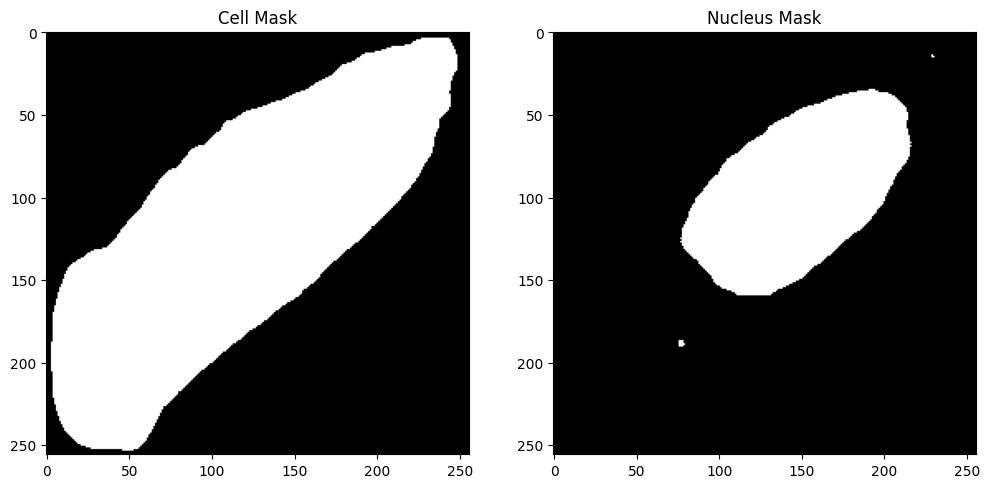

In [4]:
pil_image, input_tensor = preprocess_image(image_path)
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)    
plt.imshow(cell_mask, cmap='gray')
plt.title('Cell Mask')
plt.subplot(1, 2, 2)
plt.imshow(nucleus_mask, cmap='gray')
plt.title('Nucleus Mask')
plt.show()

In [5]:
features = extract_features(nucleus_mask, cell_mask)
df= pd.DataFrame(features, index=[1])
df

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NCExt,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr
1,10804,28256,0.382361,423.629505,793.761538,0.533699,1.0,1.0,158.685223,0.478017,...,1.343727,0.99806,0.960435,1.039175,117.286317,189.675134,0.618354,-5.075608,-11.953993,0.424595


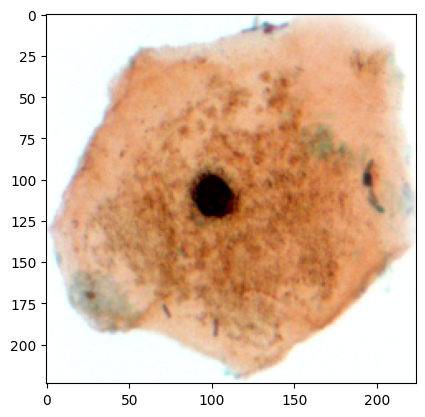

In [6]:
# image_path = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\single_all_clahe\2b_1.jpg"
image_path = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped2\NSIL\51b_1.bmp"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)


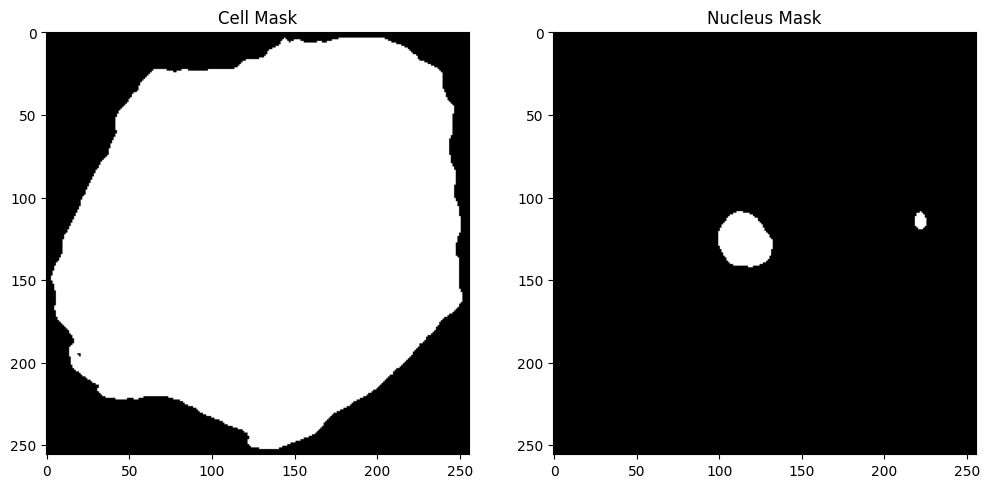

In [7]:
pil_image, input_tensor = preprocess_image(image_path)
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)    
plt.imshow(cell_mask, cmap='gray')
plt.title('Cell Mask')
plt.subplot(1, 2, 2)
plt.imshow(nucleus_mask, cmap='gray')
plt.title('Nucleus Mask')
plt.show()

In [8]:
features = extract_features(nucleus_mask, cell_mask)
df= pd.DataFrame(features, index=[1])
df

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NCExt,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr
1,896,46442,0.019293,107.740114,871.192994,0.12367,1.0,1.0,35.0,0.122665,...,1.066112,1.101414,0.963817,1.142762,33.776066,243.170292,0.138899,-5.357887,-5.989773,0.894506


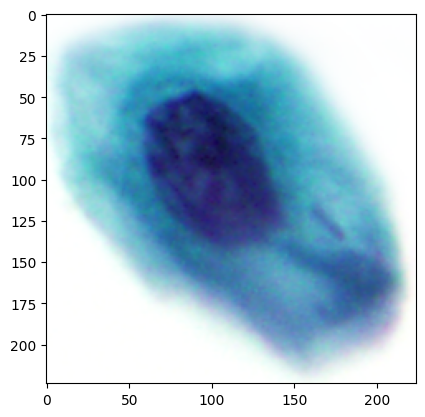

In [12]:
# image_path = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\single_all_clahe\2b_1.jpg"
image_path = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\train\LSIL\5b_1.bmp"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)


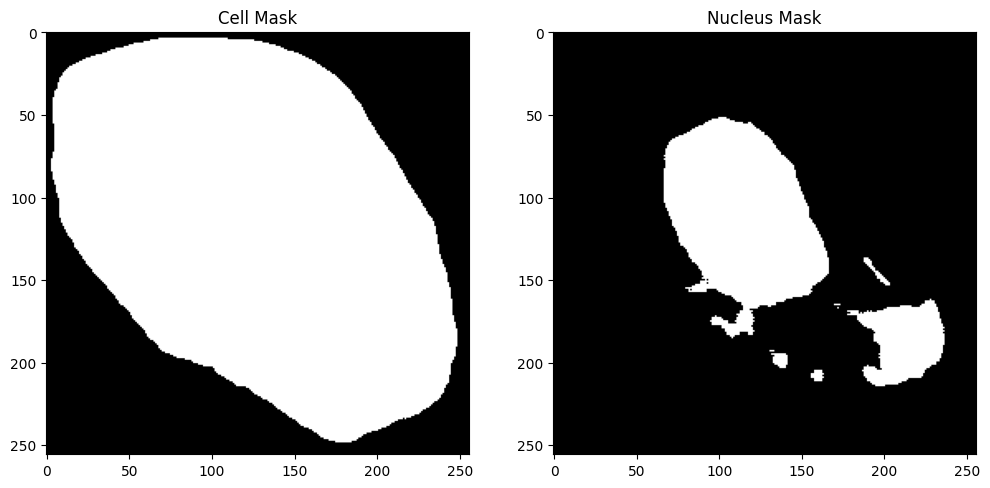

In [13]:
pil_image, input_tensor = preprocess_image(image_path)
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)    
plt.imshow(cell_mask, cmap='gray')
plt.title('Cell Mask')
plt.subplot(1, 2, 2)
plt.imshow(nucleus_mask, cmap='gray')
plt.title('Nucleus Mask')
plt.show()

In [14]:
features = extract_features(nucleus_mask, cell_mask)
df= pd.DataFrame(features, index=[1])
df

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NCExt,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr
1,10488,42379,0.247481,478.759447,815.636645,0.586976,1.0,1.0,133.240384,0.443151,...,1.113111,1.11878,0.992041,1.127755,115.558368,232.289945,0.497475,-1.257098,30.505509,-0.041209
